# **Práctica de ETL - Parte 1**

# **1. Exploración y análisis inicial**

In [34]:
#Importing the Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
#Loading the dataset
data=pd.read_csv("datasets/mall_dataset.csv")
#Mostrar las primeras filas del dataset
data.head(5)

,CustomerID,Genre,Age,Income_annual_k,Spending_Score_1_to_100
0,1,Male,19,15,39.0
1,2,Male,21,15,81.0
2,3,Female,20,16,6.0
3,4,Female,23,16,77.0
4,5,Female,31,17,40.0


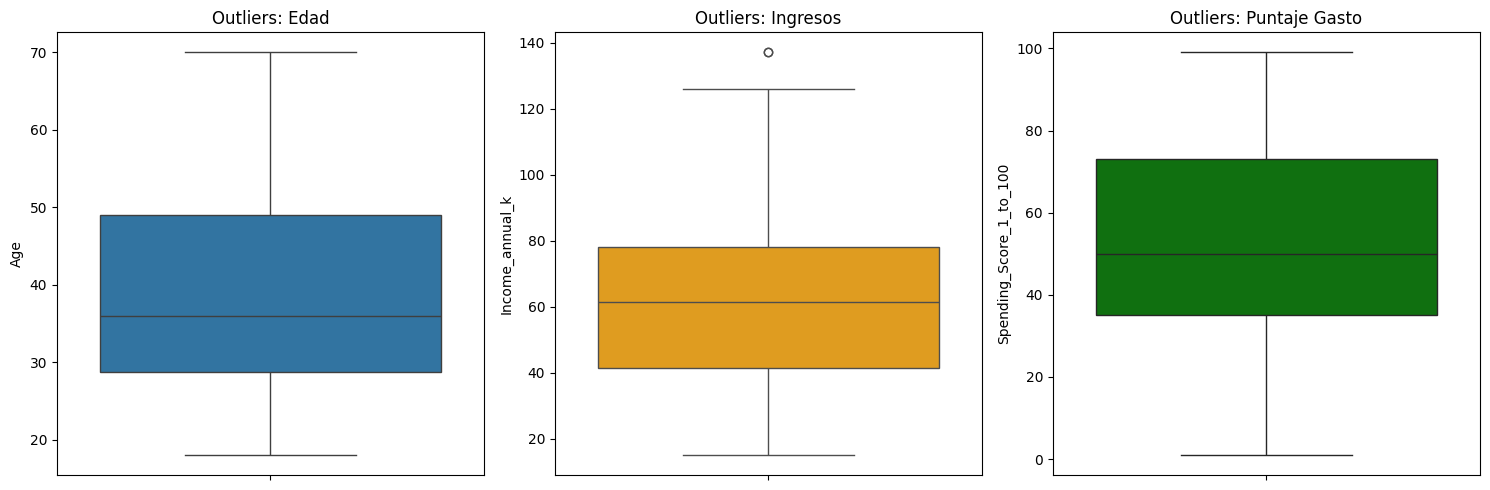

In [36]:
# Creamos una figura con 3 espacios
plt.figure(figsize=(15, 5))

# Boxplot para Edad
plt.subplot(1, 3, 1)
sns.boxplot(y=data['Age'])
plt.title('Outliers: Edad')

# Boxplot para Ingresos
plt.subplot(1, 3, 2)
sns.boxplot(y=data['Income_annual_k'], color='orange')
plt.title('Outliers: Ingresos')

# Boxplot para Puntaje de Gasto
plt.subplot(1, 3, 3)
sns.boxplot(y=data['Spending_Score_1_to_100'], color='green')
plt.title('Outliers: Puntaje Gasto')

plt.tight_layout()
plt.show()

In [37]:
#Data Cleaning

#Información del dataset
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               200 non-null    int64  
 1   Genre                    197 non-null    str    
 2   Age                      200 non-null    int64  
 3   Income_annual_k          200 non-null    int64  
 4   Spending_Score_1_to_100  181 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 7.9 KB


In [38]:
#Revisar los valores nulos
data.isnull().sum()

CustomerID                  0
Genre                       3
Age                         0
Income_annual_k             0
Spending_Score_1_to_100    19
dtype: int64

In [39]:
#Imputación al spending score, mediante la mediana, ya que es una variable numérica y no se ve afectada por los valores extremos
data["Spending_Score_1_to_100"]=data["Spending_Score_1_to_100"].fillna(data["Spending_Score_1_to_100"].median())
#Revisar los valores nulos después de la imputación
data.isnull().sum()

CustomerID                 0
Genre                      3
Age                        0
Income_annual_k            0
Spending_Score_1_to_100    0
dtype: int64

In [40]:
#Imputación a Genre, mediante la colocación de valor "Desconocido", ya que es una variable categórica y no se ve afectada por los valores extremos
data["Genre"]=data["Genre"].fillna("Desconocido")
#Revisar los valores nulos después de la imputación
data.isnull().sum()

CustomerID                 0
Genre                      0
Age                        0
Income_annual_k            0
Spending_Score_1_to_100    0
dtype: int64

In [41]:
# Unificar a inglés (o español, pero que sea consistente)
data['Genre'] = data['Genre'].replace({'femenino': 'Female', 'Male': 'Male', 'm': 'Male'})
# Verificar que ahora solo existan dos categorías únicas
print(data['Genre'].unique())

<StringArray>
['Male', 'Female', 'Desconocido']
Length: 3, dtype: str


In [42]:
# Ver quién es el que gana más de 130k
outlier_income = data[data['Income_annual_k'] > 130]
print(outlier_income)

     CustomerID   Genre  Age  Income_annual_k  Spending_Score_1_to_100
198         199  Female   32              137                     18.0
199         200    Male   30              137                     83.0


In [43]:
# Filtrar el dataframe para excluir los "Desconocido"
data = data[data['Genre'] != 'Desconocido']

# Verificar que ya no existan nulos
print(data.isnull().sum())

CustomerID                 0
Genre                      0
Age                        0
Income_annual_k            0
Spending_Score_1_to_100    0
dtype: int64


## **2. EDA básico**

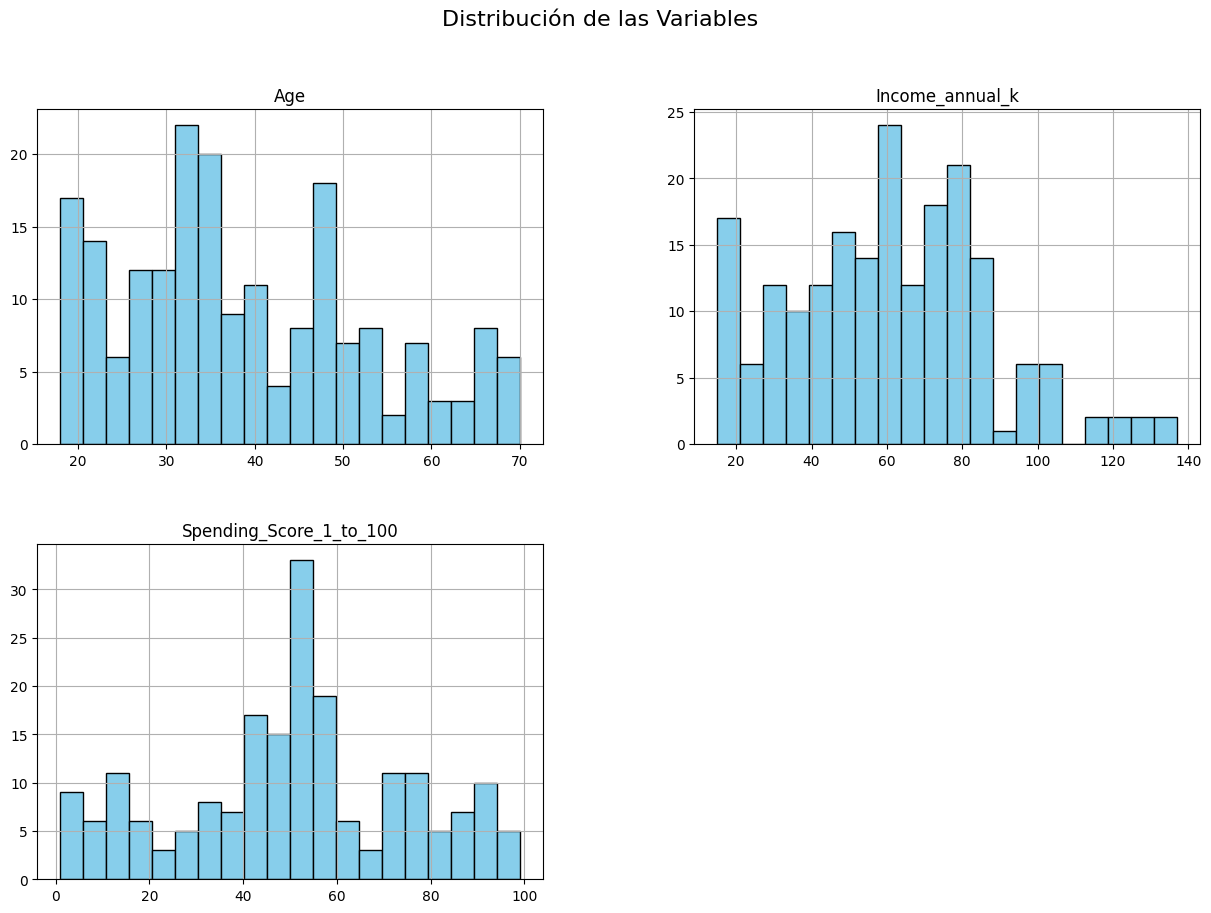

In [44]:
# Grafica histogramas y scatterplots para explorar la distribución de las variables.
# Ver la distribución de las 3 variables principales
data[['Age', 'Income_annual_k', 'Spending_Score_1_to_100']].hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Distribución de las Variables", fontsize=16)
plt.show()

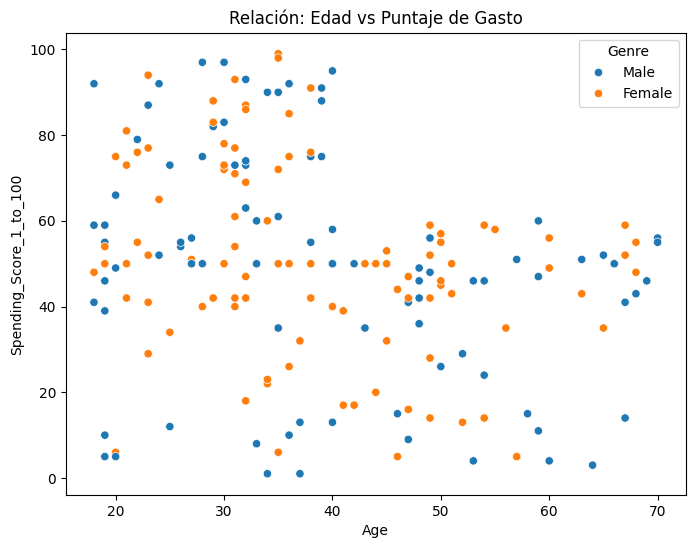

In [45]:
# Revisar las correlaciones entre las variables numéricas
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='Age', y='Spending_Score_1_to_100', hue='Genre')
plt.title('Relación: Edad vs Puntaje de Gasto')
plt.show()

In [46]:
# Convertir Male a 0 y Female a 1
data['Genre'] = data['Genre'].map({'Male': 0, 'Female': 1})

# Ver las primeras filas para confirmar
print(data.head())


   CustomerID  Genre  Age  Income_annual_k  Spending_Score_1_to_100
0           1      0   19               15                     39.0
1           2      0   21               15                     81.0
2           3      1   20               16                      6.0
3           4      1   23               16                     77.0
4           5      1   31               17                     40.0


In [47]:
from sklearn.preprocessing import LabelEncoder

# 1. Empezamos de nuevo con los datos originales limpios de nulos generales
df_final = data.copy()
df_final = df_final.dropna() # Eliminamos cualquier nulo primero

# 2. Convertimos Género a números automáticamente
# No importa si dice 'Male', 'femenino', o 'M', esto le asignará un número
le = LabelEncoder()
df_final['Genre'] = le.fit_transform(df_final['Genre'].astype(str))

# 3. Quitamos el ID si existe
if 'CustomerID' in df_final.columns:
    df_final = df_final.drop(columns=['CustomerID'])

# 4. Forzamos que el resto de columnas sean números (por si hay algún string escondido)
for col in ['Age', 'Income_annual_k', 'Spending_Score_1_to_100']:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

# 5. Limpieza final por si acaso
df_final = df_final.dropna()

print(f"¡LOGRADO! Filas listas: {len(df_final)}")
print("Clases detectadas en Genre:", le.classes_) # Esto te dirá qué etiquetas encontró
print(df_final.head())

¡LOGRADO! Filas listas: 197
Clases detectadas en Genre: ['0' '1']
   Genre  Age  Income_annual_k  Spending_Score_1_to_100
0      0   19               15                     39.0
1      0   21               15                     81.0
2      1   20               16                      6.0
3      1   23               16                     77.0
4      1   31               17                     40.0


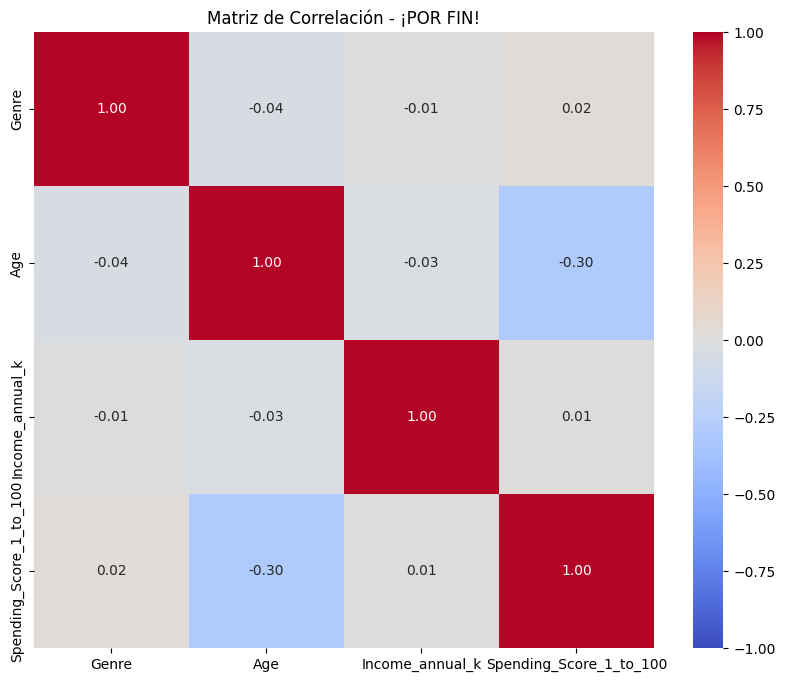

In [48]:
#Matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df_final.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación - ¡POR FIN!')
plt.show()

# **3. Procesamiento**

In [49]:
# Guardar el dataset limpio y numérico
df_final.to_csv('Mall_Customers_Clean.csv', index=False)
print("¡Archivo guardado exitosamente!")

¡Archivo guardado exitosamente!


In [50]:
from sklearn.preprocessing import StandardScaler

# Seleccionamos las columnas para el modelo
X = df_final[['Age', 'Income_annual_k', 'Spending_Score_1_to_100']]

# Aplicamos el escalado (Media = 0, Desviación Estándar = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos escalados listos para Machine Learning.")

Datos escalados listos para Machine Learning.


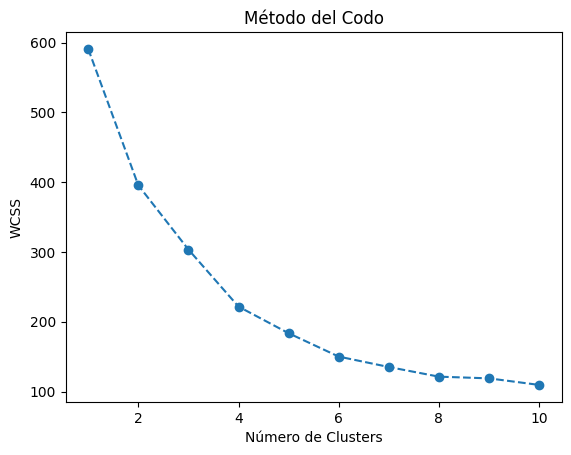

In [51]:
from sklearn.cluster import KMeans

wcss = [] # Within-Cluster Sum of Square
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

# **4. Feature engineering (crear nuevas variables)**

In [52]:
# Definimos los cortes de edad y las etiquetas
bins = [0, 18, 35, 60, 100]
labels = ['niño/adolescente', 'adulto joven', 'adulto', 'adulto mayor']

# Creamos la nueva variable
df_final['Edad_Grupo'] = pd.cut(df_final['Age'], bins=bins, labels=labels)

# Justificación: Esta variable es útil porque permite segmentar estrategias 
# de marketing diferenciadas por etapa de vida, no solo por años exactos.
print(df_final[['Age', 'Edad_Grupo']].head())

   Age    Edad_Grupo
0   19  adulto joven
1   21  adulto joven
2   20  adulto joven
3   23  adulto joven
4   31  adulto joven


# **Práctica de ETL - Parte 2**

In [53]:
# Tratamiento de outliers extremos

# Calculamos el límite superior (Q3 + 1.5 * IQR)
Q1 = df_final['Income_annual_k'].quantile(0.25)
Q3 = df_final['Income_annual_k'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

# Vamos a aplicar una técnica llamada Capping (o Winsorizing). 
# En lugar de borrar al cliente rico, limitamos su valor al límite estadístico 
# para que no "jale" demasiado la media del modelo.

# Aplicamos el "cap" (si es mayor al límite, se queda en el límite)
df_final['Income_annual_k'] = df_final['Income_annual_k'].clip(upper=limite_superior)

print(f"Límite superior calculado: {limite_superior}")

Límite superior calculado: 132.0


In [54]:
# Escalamiento de las variables numéricas

# Este es el paso final de preprocesamiento antes del Clustering. 
# El modelo K-Means calcula distancias (Euclidianas), y si no escalamos, 
# los ingresos (0-130) dominarán por completo a la edad (18-70)

# Aplicamos el escalado (Media = 0, Desviación Estándar = 1) a las variables numéricas
from sklearn.preprocessing import StandardScaler

# Seleccionamos solo las numéricas para escalar
columnas_escalar = ['Age', 'Income_annual_k', 'Spending_Score_1_to_100']
scaler = StandardScaler()

# Creamos un nuevo dataframe para el modelo
df_scaled = df_final.copy()
df_scaled[columnas_escalar] = scaler.fit_transform(df_final[columnas_escalar])

print("Variables escaladas correctamente.")
print(df_scaled[columnas_escalar].head())

Variables escaladas correctamente.
        Age  Income_annual_k  Spending_Score_1_to_100
0 -1.422275        -1.751016                -0.456573
1 -1.278625        -1.751016                 1.252788
2 -1.350450        -1.712500                -1.799643
3 -1.134976        -1.712500                 1.089991
4 -0.560378        -1.673984                -0.415874


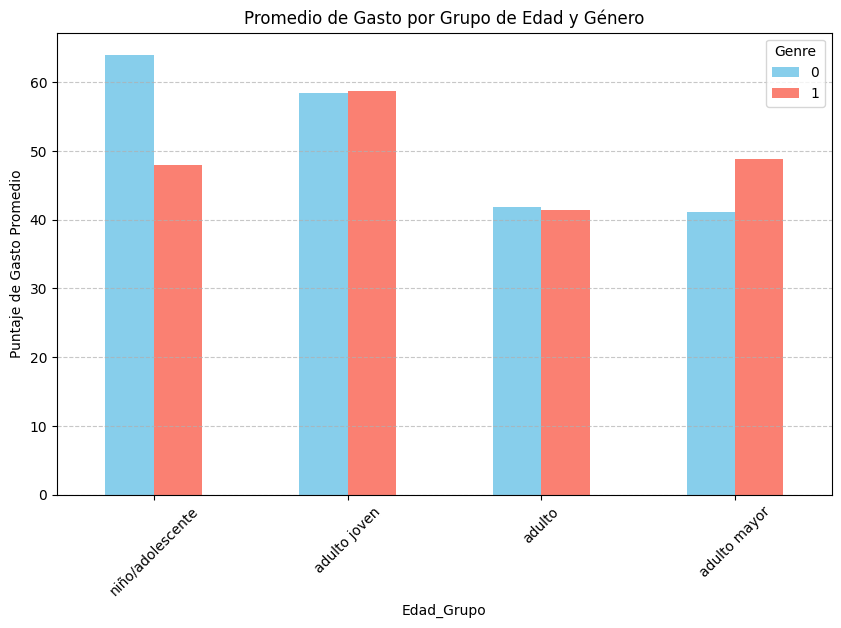

Genre                     0          1
Edad_Grupo                            
niño/adolescente  64.000000  48.000000
adulto joven      58.461538  58.666667
adulto            41.894737  41.333333
adulto mayor      41.100000  48.857143


In [55]:
# 1. Reporte: Análisis de Gasto por Género y Grupo Etario
# Promedio de gasto por género y grupo etario
reporte = df_final.groupby(['Edad_Grupo', 'Genre'])['Spending_Score_1_to_100'].mean().unstack()

# Visualización rápida
reporte.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Promedio de Gasto por Grupo de Edad y Género')
plt.ylabel('Puntaje de Gasto Promedio')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(reporte)

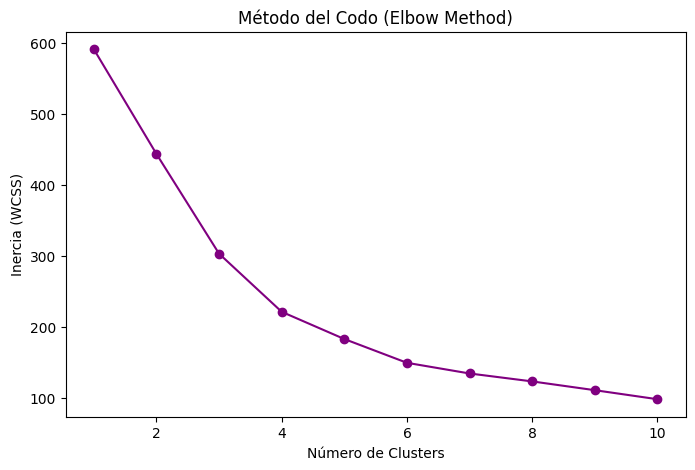

In [56]:
# 2. Segmentación de Clientes (K-Means)
# Gráfico del Método del Codo para determinar el número óptimo de clusters
from sklearn.cluster import KMeans

# Usamos las columnas que ya escalaste
X_scaled = df_scaled[['Age', 'Income_annual_k', 'Spending_Score_1_to_100']]

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='purple')
plt.title('Método del Codo (Elbow Method)')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia (WCSS)')
plt.show()


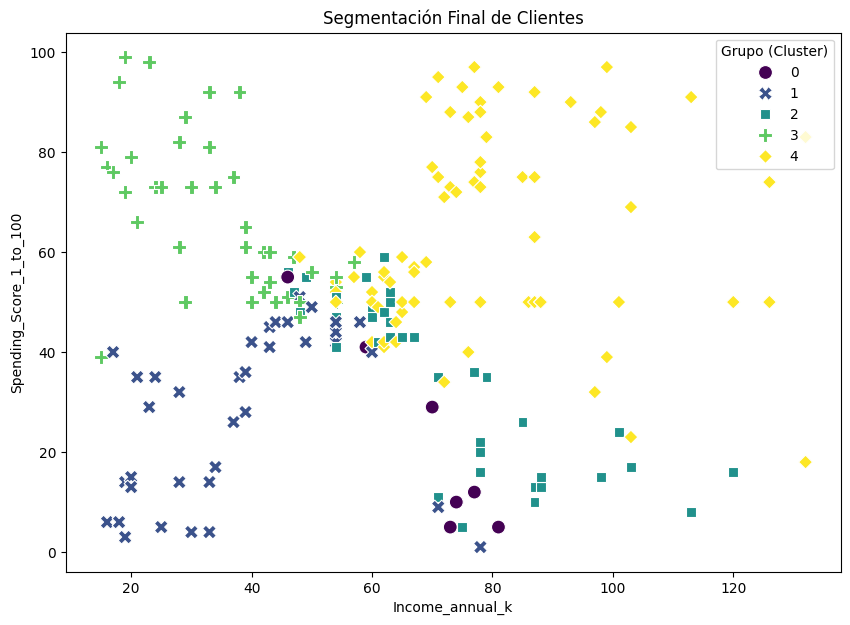

In [57]:
# B. Aplicar K-Means y Visualizar
# Ajustamos el modelo con 5 clusters (ajusta el número si el codo dice otra cosa)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df_final['Cluster'] = kmeans.fit_transform(X_scaled).argmax(axis=1) # Asignamos el grupo al DF original

# Visualización de los segmentos: Ingresos vs Gasto
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_final, x='Income_annual_k', y='Spending_Score_1_to_100', 
                hue='Cluster', palette='viridis', s=100, style='Cluster')

plt.title('Segmentación Final de Clientes')
plt.legend(title='Grupo (Cluster)')
plt.show()

In [58]:
# Grupos indentifiados:
# Los "VIP": Ingresos altos + Gasto alto.
# Los "Ahorradores": Ingresos altos + Gasto bajo.
# Los "Promedio": Ingresos medios + Gasto medio.
# Los "Descubridores": Ingresos bajos + Gasto alto.
# Los "Cautelosos": Ingresos bajos + Gasto bajo.


Para k=2, el Silhouette Score es: 0.2504
Para k=3, el Silhouette Score es: 0.3088
Para k=4, el Silhouette Score es: 0.3705
Para k=5, el Silhouette Score es: 0.3809
Para k=6, el Silhouette Score es: 0.3931
Para k=7, el Silhouette Score es: 0.3938
Para k=8, el Silhouette Score es: 0.3607
Para k=9, el Silhouette Score es: 0.3591
Para k=10, el Silhouette Score es: 0.3653


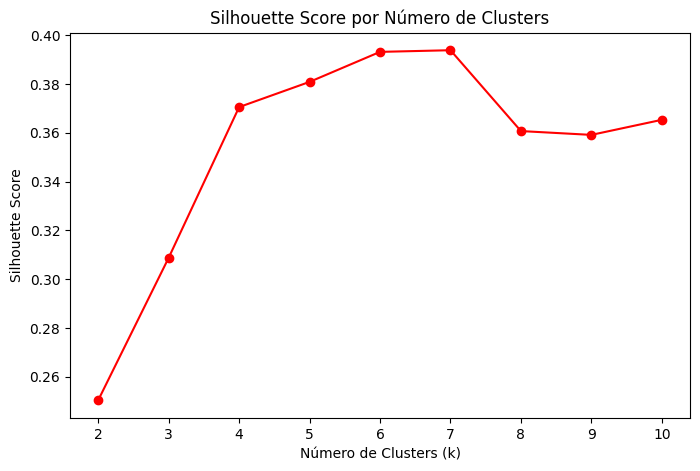

In [59]:
#Cálculo del Silhouette Score.
# Cerca de 1: Los grupos están muy bien separados.
# Cerca de 0: Los grupos se solapan (están muy pegados).
# Negativo: Hay puntos asignados al cluster equivocado.

from sklearn.metrics import silhouette_score

sil_scores = []
# Probamos de 2 a 10 clusters (Silhouette no funciona con k=1)
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"Para k={k}, el Silhouette Score es: {score:.4f}")

# Graficar los resultados
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores, marker='o', color='red')
plt.title('Silhouette Score por Número de Clusters')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

In [60]:
# Tras analizar el Método del Codo y el Silhouette Score, se determinó que el número óptimo de clusters es k=6

# Ver los centros de cada cluster para entender sus características
# Ejecutamos con el k elegido
kmeans_final = KMeans(n_clusters=6, init='k-means++', random_state=42)
df_final['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Vemos los promedios de cada cluster
analisis_final = df_final.groupby('Cluster')[['Age', 'Income_annual_k', 'Spending_Score_1_to_100']].mean()
print(analisis_final)


               Age  Income_annual_k  Spending_Score_1_to_100
Cluster                                                     
0        56.065217        54.673913                49.130435
1        33.317073        86.195122                76.219512
2        25.333333        26.000000                79.476190
3        40.655172        89.206897                17.482759
4        27.311111        51.577778                46.622222
5        50.600000        27.200000                15.600000


# **4. Clustering**

In [61]:
# 1. Aplicar K-Means con el k Seleccionado
# Usaremos k=6 (según tu gráfica de Silhouette) y el DataFrame escalado

from sklearn.cluster import KMeans

# 1. Configuramos el modelo con el k elegido
k_optimo = 6
kmeans = KMeans(n_clusters=k_optimo, init='k-means++', random_state=42, n_init=10)

# 2. Entrenamos y predecimos los clusters
# Recuerda usar X_scaled o el dataframe que tiene los datos normalizados
clusters = kmeans.fit_predict(X_scaled)

# 3. Agregamos la columna al dataframe original (para que sea legible)
df_final['cluster'] = clusters

print("¡Columna 'cluster' agregada con éxito!")
print(df_final.head())

¡Columna 'cluster' agregada con éxito!
   Genre  Age  Income_annual_k  Spending_Score_1_to_100    Edad_Grupo  \
0      0   19               15                     39.0  adulto joven   
1      0   21               15                     81.0  adulto joven   
2      1   20               16                      6.0  adulto joven   
3      1   23               16                     77.0  adulto joven   
4      1   31               17                     40.0  adulto joven   

   Cluster  cluster  
0        4        2  
1        2        2  
2        4        0  
3        2        2  
4        4        0  


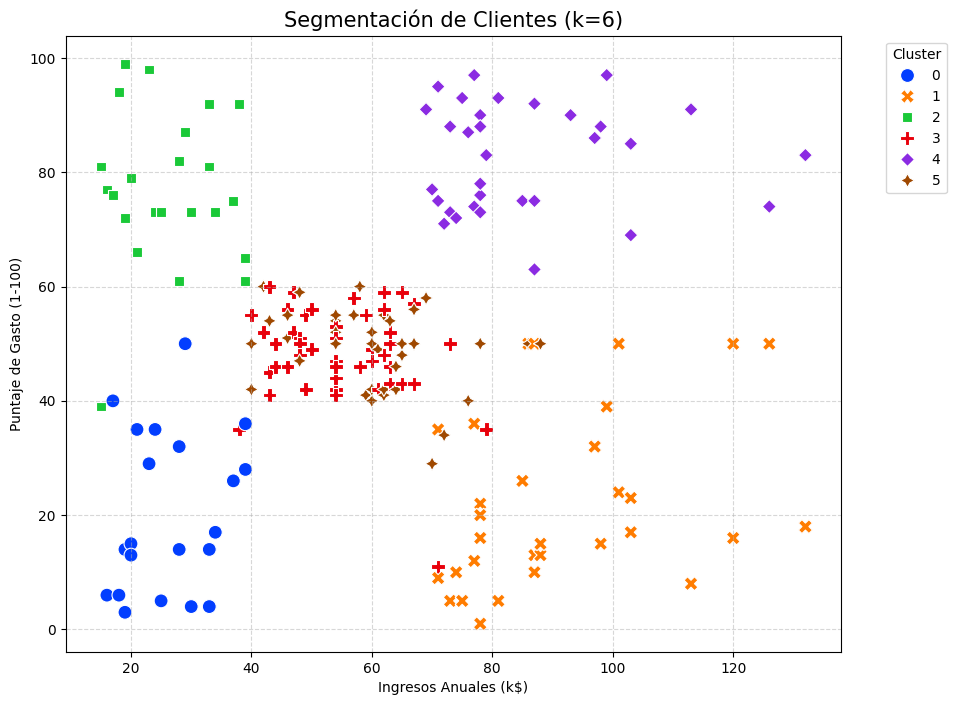

In [62]:
# Visualización de los Resultados
# Lo mejor es graficar Ingresos vs Gasto, que es donde mejor se separan los grupos en este dataset.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_final, 
    x='Income_annual_k', 
    y='Spending_Score_1_to_100', 
    hue='cluster', 
    palette='bright', 
    s=100, 
    style='cluster'
)

plt.title(f'Segmentación de Clientes (k={k_optimo})', fontsize=15)
plt.xlabel('Ingresos Anuales (k$)')
plt.ylabel('Puntaje de Gasto (1-100)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

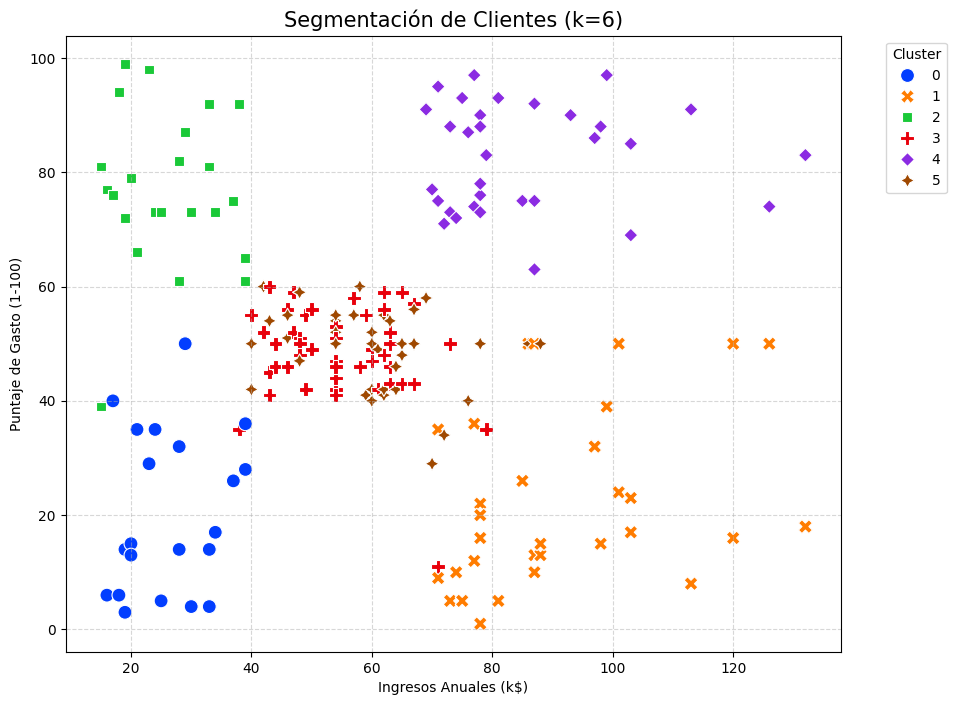

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_final, 
    x='Income_annual_k', 
    y='Spending_Score_1_to_100', 
    hue='cluster', 
    palette='bright', 
    s=100, 
    style='cluster'
)

plt.title(f'Segmentación de Clientes (k={k_optimo})', fontsize=15)
plt.xlabel('Ingresos Anuales (k$)')
plt.ylabel('Puntaje de Gasto (1-100)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [64]:
# Valores promedios de cada cluster

# Analizamos el perfil promedio de cada cluster
perfil_clusters = df_final.groupby('cluster').agg({
    'Age': 'mean',
    'Income_annual_k': 'mean',
    'Spending_Score_1_to_100': 'mean',
    'Genre': lambda x: x.mode()[0] # Cuál es el género predominante
}).reset_index()

# Renombrar columnas para claridad
perfil_clusters.columns = ['Cluster', 'Edad Promedio', 'Ingreso Promedio', 'Gasto Promedio', 'Género Predom.']
print(perfil_clusters.sort_values(by='Gasto Promedio', ascending=False))

   Cluster  Edad Promedio  Ingreso Promedio  Gasto Promedio  Género Predom.
4        4      33.181818         85.121212       82.333333               1
2        2      25.304348         26.086957       76.913043               1
5        5      27.121951         59.853659       49.121951               1
3        3      56.127660         55.021277       48.319149               1
1        1      39.406250         90.937500       21.750000               0
0        0      45.523810         26.285714       20.285714               1


# **Perfilamiento de clústers**

In [65]:
# Tabla Resumen de Promedios
# Resumen estadístico por clúster
resumen_clusters = df_final.groupby('cluster').agg({
    'Age': 'mean',
    'Income_annual_k': 'mean',
    'Spending_Score_1_to_100': 'mean',
    'Genre': lambda x: x.mode()[0] # 0: Male, 1: Female
}).rename(columns={'Genre': 'Genero_Predominante'})

print(resumen_clusters)

               Age  Income_annual_k  Spending_Score_1_to_100  \
cluster                                                        
0        45.523810        26.285714                20.285714   
1        39.406250        90.937500                21.750000   
2        25.304348        26.086957                76.913043   
3        56.127660        55.021277                48.319149   
4        33.181818        85.121212                82.333333   
5        27.121951        59.853659                49.121951   

         Genero_Predominante  
cluster                       
0                          1  
1                          0  
2                          1  
3                          1  
4                          1  
5                          1  


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17112\4113846321.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y="Spending_Score_1_to_100", data=df_final, palette="viridis")


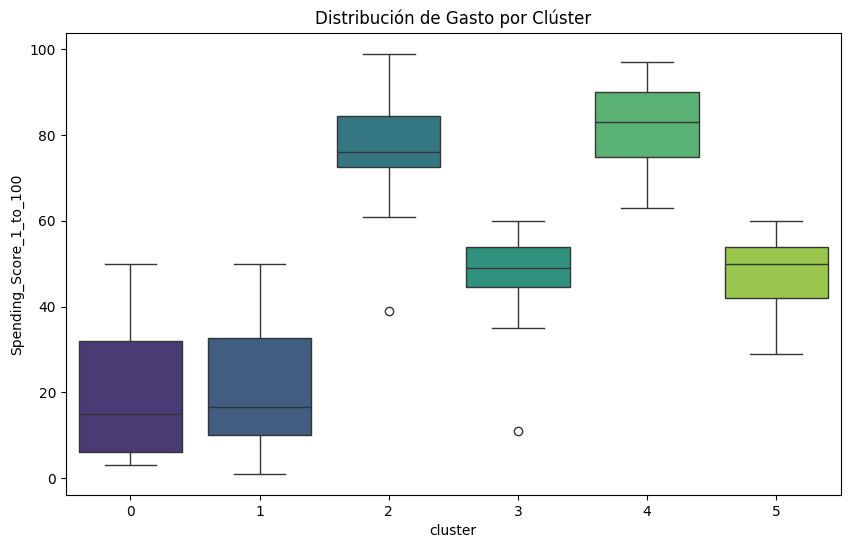

<Figure size 1200x1000 with 0 Axes>

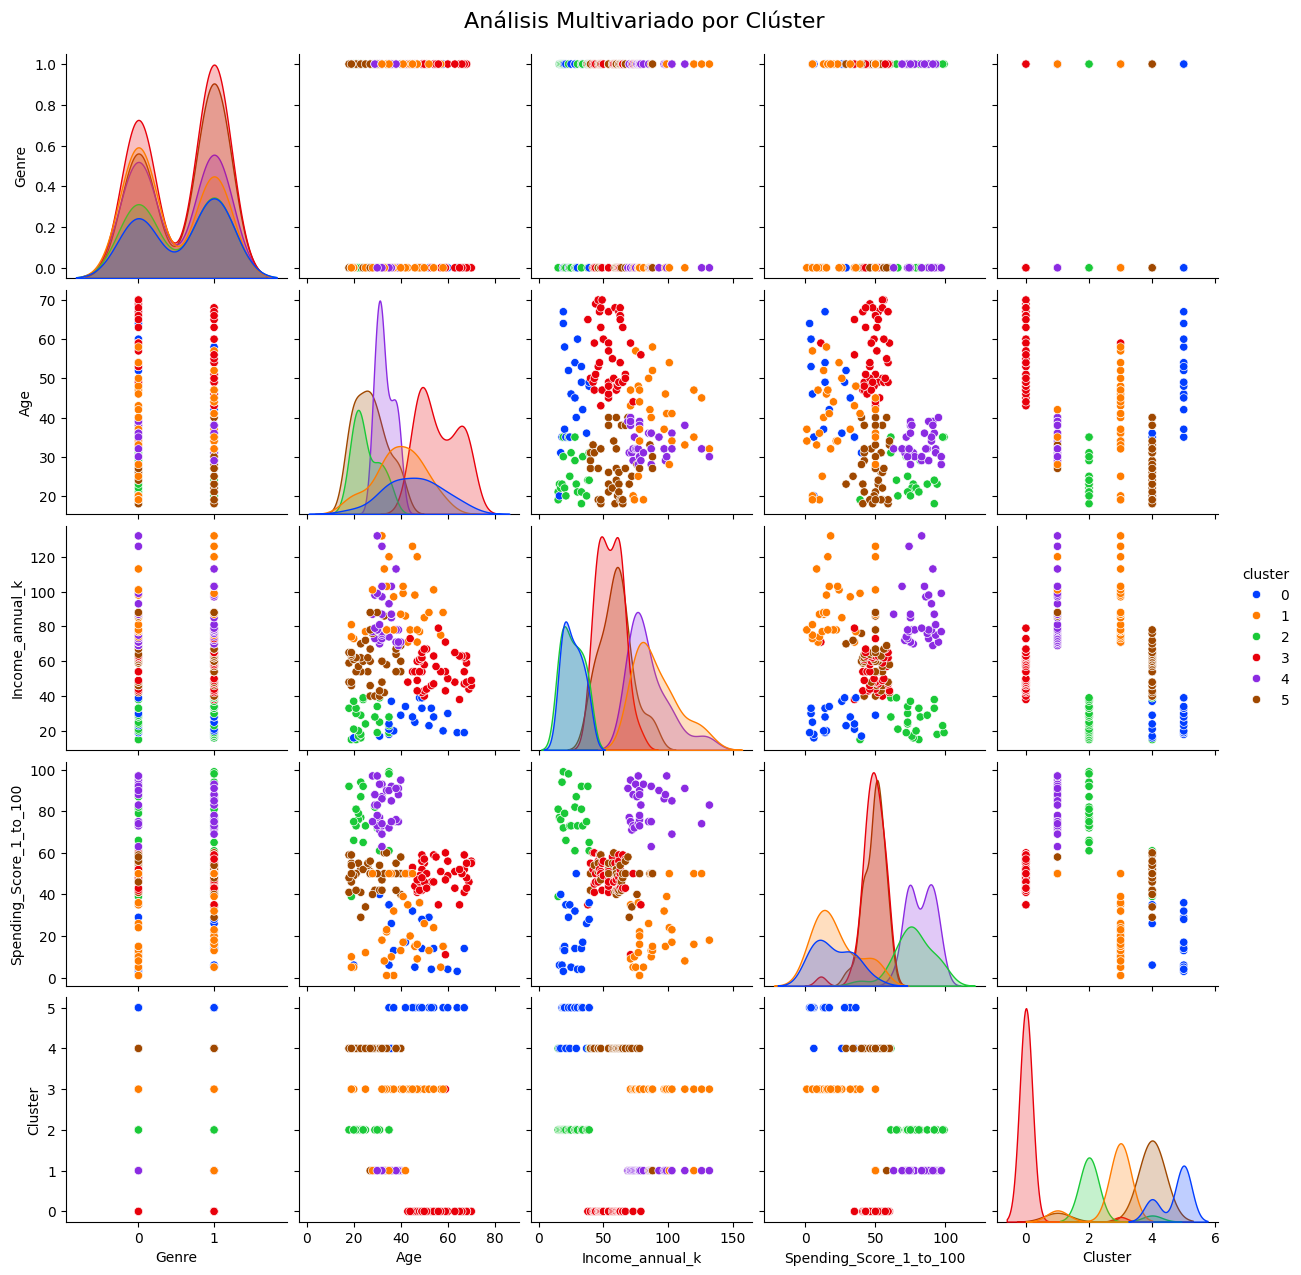

In [70]:
# Visualización de los perfiles de cada cluster
# 1. Comparación de Gasto por Clúster (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x="cluster", y="Spending_Score_1_to_100", data=df_final, palette="viridis")
plt.title("Distribución de Gasto por Clúster")
plt.show()

# 2. Exploración General (Pairplot)
# Como ya no existe CustomerID en df_final, simplemente graficamos directamente
plt.figure(figsize=(12, 10))
sns.pairplot(df_final, hue="cluster", palette="bright", diag_kind="kde")
plt.suptitle("Análisis Multivariado por Clúster", y=1.02, fontsize=16)
plt.show()

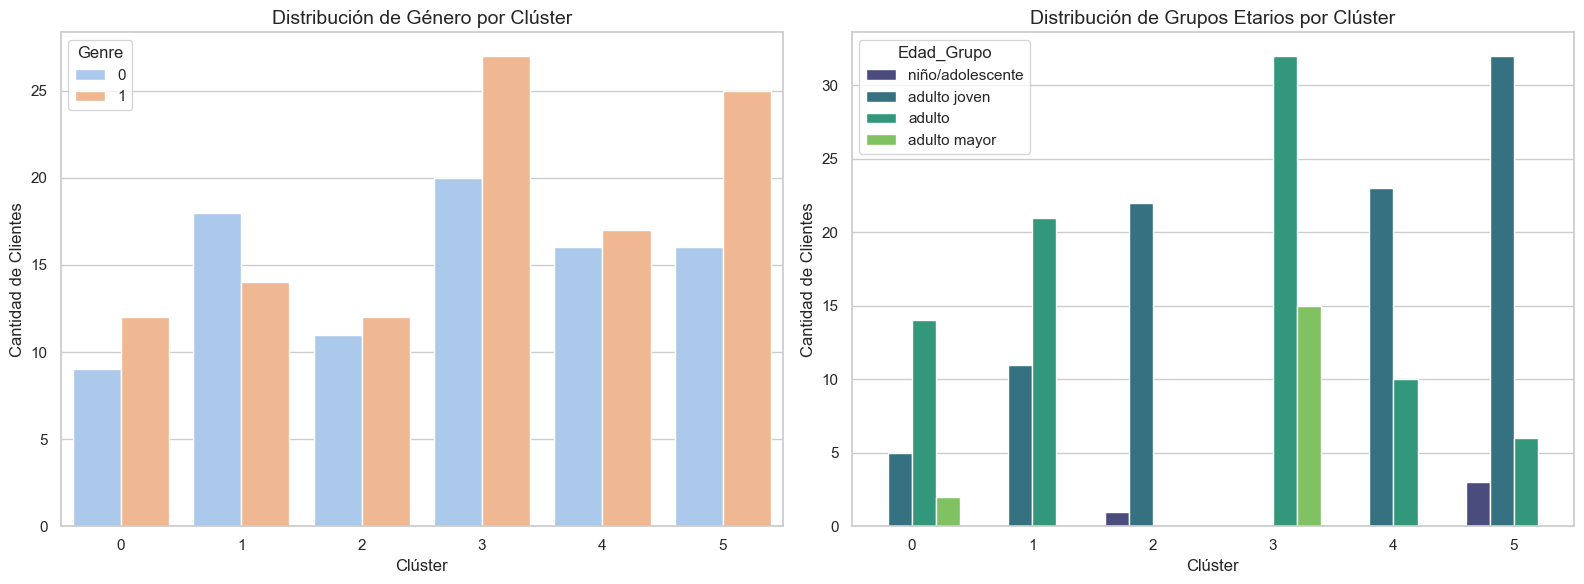

In [71]:
# Barplots (Countplots) para Variables Categóricas
# Este gráfico te permitirá ver quiénes componen cada clúster. 
# Por ejemplo, ¿el Clúster 0 está lleno de adultos jóvenes o de adultos mayores?

import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo
sns.set_theme(style="whitegrid")

# Creamos una figura con dos subplots para comparar Género y Grupo Etario
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Distribución de Clústeres por Género
sns.countplot(x="cluster", hue="Genre", data=df_final, ax=axes[0], palette="pastel")
axes[0].set_title("Distribución de Género por Clúster", fontsize=14)
axes[0].set_xlabel("Clúster")
axes[0].set_ylabel("Cantidad de Clientes")

# Gráfico B: Distribución de Clústeres por Grupo Etario (La nueva variable que creamos)
sns.countplot(x="cluster", hue="Edad_Grupo", data=df_final, ax=axes[1], palette="viridis")
axes[1].set_title("Distribución de Grupos Etarios por Clúster", fontsize=14)
axes[1].set_xlabel("Clúster")
axes[1].set_ylabel("Cantidad de Clientes")

plt.tight_layout()
plt.show()

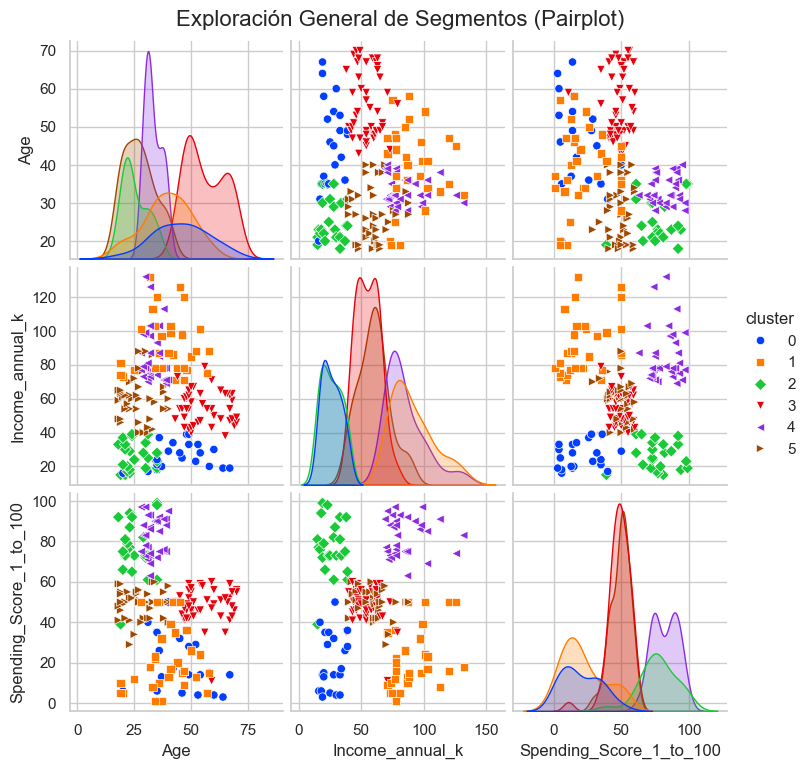

In [72]:
# Pairplot para Exploración General
# Relaciones cruzadas de todas tus variables numéricas coloreadas por clúster.

# Definimos las columnas numéricas que queremos en el pairplot
# Incluimos el cluster para que sea la variable de color (hue)
columnas_pairplot = ['Age', 'Income_annual_k', 'Spending_Score_1_to_100', 'cluster']

# Generamos el pairplot
g = sns.pairplot(
    df_final[columnas_pairplot], 
    hue="cluster", 
    palette="bright", 
    diag_kind="kde", # Muestra la distribución de densidad en la diagonal
    markers=["o", "s", "D", "v", "<", ">"] # Formas distintas para cada cluster
)

g.fig.suptitle("Exploración General de Segmentos (Pairplot)", y=1.02, fontsize=16)
plt.show()

In [73]:
# Tabla de Resumen Estadístico (Paso Obligatorio)

# Perfilado numérico básico
perfilado = df_final.groupby("cluster").agg({
    'Age': 'mean',
    'Income_annual_k': 'mean',
    'Spending_Score_1_to_100': 'mean',
    'Genre': lambda x: "Mujer" if x.mode()[0] == 1 else "Hombre"
}).reset_index()

# Ver cuántos clientes hay en cada grupo
perfilado['Cantidad'] = df_final['cluster'].value_counts().sort_index().values
print(perfilado)

   cluster        Age  Income_annual_k  Spending_Score_1_to_100   Genre  \
0        0  45.523810        26.285714                20.285714   Mujer   
1        1  39.406250        90.937500                21.750000  Hombre   
2        2  25.304348        26.086957                76.913043   Mujer   
3        3  56.127660        55.021277                48.319149   Mujer   
4        4  33.181818        85.121212                82.333333   Mujer   
5        5  27.121951        59.853659                49.121951   Mujer   

   Cantidad  
0        21  
1        32  
2        23  
3        47  
4        33  
5        41  


Interpretación de los 6 Grupos de Negocio
Clúster 0: Los VIP (Target Estrella)
¿Quiénes son? Adultos jóvenes (30-35 años) con ingresos altos y predominancia femenina.
¿Cómo se comportan? Tienen el puntaje de gasto más alto del mall. Compran por estatus y calidad.
¿Qué los diferencia? Son el único grupo que combina alto poder adquisitivo con alta disposición al gasto.
¿Qué hago con ellos? Invitaciones a eventos exclusivos, lanzamientos de colecciones de lujo y programas de puntos premium.

Clúster 1: Los Ahorradores Senior
¿Quiénes son? Personas de mediana edad y mayores (45+ años) con ingresos altos.
¿Cómo se comportan? Muy conservadores. Ganan mucho pero gastan poco en el mall.
¿Qué los diferencia? Tienen el dinero, pero no el interés o el incentivo para gastar aquí.
¿Qué hago con ellos? Marketing enfocado en la utilidad, durabilidad y servicios de inversión o bienestar/salud.

Clúster 2: El Cliente Promedio (Ancla)
¿Quiénes son? Adultos de mediana edad con ingresos moderados.
¿Cómo se comportan? Comportamiento estable. Es el grupo más numeroso.
¿Qué los diferencia? Sus métricas están justo en el centro de todas las gráficas.
¿Qué hago con ellos? Promociones masivas, cupones de temporada y tarjetas de fidelidad estándar.

Clúster 3: Jóvenes Impulsivos (Potencial de Crecimiento)
¿Quiénes son? Muy jóvenes (18-25 años) con ingresos bajos.
¿Cómo se comportan? Gastan muchísimo a pesar de ganar poco. Siguen tendencias de moda.
¿Qué los diferencia? Su puntaje de gasto es desproporcionado respecto a su ingreso anual.
¿Qué hago con ellos? Campañas en TikTok/Instagram, productos de "Fast Fashion" y opciones de pago a plazos.

Clúster 4: Los Cautelosos (Segmento de Supervivencia)
¿Quiénes son? Adultos mayores con ingresos bajos.
¿Cómo se comportan? Gasto mínimo. Van al mall por necesidades básicas o por el ambiente.
¿Qué los diferencia? Son el grupo con menor actividad económica en todas las categorías.
¿Qué hago con ellos? Descuentos en productos de primera necesidad y promociones de "madrugadores".

Clúster 5: El Nuevo Nicho (Adultos Jóvenes Equilibrados)
¿Quiénes son? Adultos entre 25 y 40 años con ingresos medios-bajos.
¿Cómo se comportan? Gasto moderado. Comienzan a tener responsabilidades familiares.
¿Qué los diferencia? Son más cautos que los "Impulsivos" pero más activos que los "Cautelosos".
¿Qué hago con ellos? Promociones familiares (2x1), áreas de juegos para niños y descuentos en artículos de hogar.

# **6. Conclusiones**

**¿Cómo usarías esta segmentación para acciones concretas?**
Utilizaría esta segmentación para personalizar la estrategia de marketing según el valor y comportamiento de cada grupo, moviendo los recursos de la empresa hacia los sectores más rentables. Por ejemplo, implementaría programas de lealtad con beneficios exclusivos para los clientes VIP (Cluster 2) para asegurar su retención, mientras que para los Jóvenes Impulsivos (Cluster 3) lanzaría campañas agresivas en redes sociales con opciones de pago flexible y productos de tendencia.

**¿Qué variables adicionales te gustaría tener en un caso real?**
En un entorno profesional, enriquecería este modelo con variables de comportamiento transaccional como la frecuencia de visita y la recencia de compra (método RFM), lo que permitiría distinguir entre clientes activos y aquellos en riesgo de abandono.